# Ticketmaster API Explorer
This notebook interacts with the Ticketmaster Discovery API to query events and venues in the UK.

## 1. Imports & Setup

In [19]:
import requests
import os
import re
import time
from typing import Optional
from dotenv import load_dotenv
from pprint import pprint
import pandas as pd
import matplotlib.pyplot as plt

## 2. Configuration
Load the API key from the `.env` file and define base URL constants.

In [2]:
load_dotenv()

API_KEY = os.getenv("TICKET_API")

if not API_KEY:
    raise ValueError("That API key is not in your env, check your env for the correct variable name.")

BASE_URL = "https://app.ticketmaster.com"

EVENTS_ENDPOINT = "/discovery/v2/events"
VENUES_ENDPOINT = "/discovery/v2/venues"

print("Config loaded successfully.")

Config loaded successfully.


## 3. Events
Query the Ticketmaster Discovery API for events in the UK.

In [ ]:
api_key = API_KEY
all_events = []
current_page = 0
total_pages = 1 

while current_page < total_pages:
    events_url = f"{BASE_URL}{EVENTS_ENDPOINT}.json?apikey={api_key}&countryCode=GB&size=200&page={current_page}"
    events_response = requests.get(events_url).json()

    page_events = events_response.get('_embedded', {}).get('events', [])
    all_events.extend(page_events)

    total_pages = events_response.get('page', {}).get('totalPages', 1)
    current_page += 1

print(f"Successfully collected {len(all_events)} events total!")

Successfully collected 1200 events total!


In [4]:
uk_events = []


for event in all_events:
    class_list = event.get("classifications") or []
    cls = class_list[0] if class_list else {}

    venue_list = event.get("_embedded", {}).get("venues") or []
    vn = venue_list[0] if venue_list else {}

    market_list = vn.get("markets") or []
    mkt = market_list[0] if market_list else {}
    event_data = {
        "event_id": event.get("id"),
        "name": event.get("name"),
        "date": event.get("dates", {}).get("start", {}).get("localDate"),
        "time": event.get("dates", {}).get("start", {}).get("localTime"),
        "multi_day_event": event.get("dates", {}).get("spanMultipleDays"),
        "legal_age_enforced": event.get("ageRestrictions", {}).get("legalAgeEnforced"),

        "category_segment": cls.get("segment", {}).get("name"),
        "category_genre": cls.get("genre", {}).get("name"),
        "category_sub_genre": cls.get("subGenre", {}).get("name"),

        "all_inclusive_pricing": event.get("ticketing", {}).get("allInclusivePricing", {}).get("enabled"),

        "venue_id": vn.get("id"),
        "venue_name": vn.get("name"),
        "address": vn.get("address", {}).get("line1"),
        "postcode": vn.get("postalCode"),
        "city": vn.get("city", {}).get("name"),
        "longitude": vn.get("location", {}).get("longitude"),
        "latitude": vn.get("location", {}).get("latitude"),

        "markets": mkt.get("name"),
        "markets_id": mkt.get("id"),
        "url": event.get("url")
    }

    uk_events.append(event_data)

In [5]:
# implement pydantic validation

In [6]:
df_events = pd.DataFrame(uk_events)
df_events.head()

,event_id,name,date,time,multi_day_event,legal_age_enforced,category_segment,category_genre,category_sub_genre,all_inclusive_pricing,venue_id,venue_name,address,postcode,city,longitude,latitude,markets,markets_id,url
0,17u8v0G6Cr7i1p0,Philadelphia Eagles v Jacksonville Jaguars,2026-10-11,14:30:00,False,False,Sports,Football,NFL,False,KovZ9177OxV,Tottenham Hotspur Stadium,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.eticketing.co.uk/nfl-tottenham?utm...
1,17FYv0G65mKlspy,NFL London 2026: Houston Texans v Jacksonville...,2026-10-18,14:30:00,False,False,Sports,Football,NFL,False,KovZ9177ML0,Wembley Stadium,Wembley,HA9 0WS,London,-0.27958100,51.55780700,All of United Kingdom,201,https://www.eticketing.co.uk/jaguars/EDP/Event...
2,17u8v0G6CksBAD4,JAY-Z - 30,2026-09-04,17:00:00,False,False,Music,Hip-Hop/Rap,Trap,False,KovZ9177OxV,Tottenham Hotspur Stadium,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.ticketmaster.co.uk/jayz-30-london-...
3,17u8v0G6Cr7i1px,Indianapolis Colts v Washington Commanders,2026-10-04,14:30:00,False,False,Sports,Football,NFL,False,KovZ9177OxV,Tottenham Hotspur Stadium,782 High Rd,N17 0BX,London,-0.06787000,51.60081900,All of United Kingdom,201,https://www.eticketing.co.uk/nfl-tottenham?utm...
4,1AdjZbsGkiuENAI,Harry Potter and the Cursed Child - Parts 1 & ...,2026-07-10,14:00:00,False,False,Arts & Theatre,Theatre,Drama,False,KovZ9177gU0,Palace Theatre,"Cambridge Circus, Shaftesbury Avenue",W1D 8AY,London,-0.12970730,51.51316680,All of United Kingdom,201,https://theatre.ticketmaster.co.uk/book/17YYA-...


In [7]:
df_events.shape

(1200, 20)

# EDA

In [17]:
df_eda = df_events.copy()

city_counts = df_eda.groupby("city")["event_id"].count().reset_index(name = "event_count")

city_counts = city_counts.sort_values(by = "event_count", ascending = False).reset_index(drop = True)

In [18]:
city_counts.head()

,city,event_count
0,London,847
1,Bristol,66
2,Manchester,53
3,Glasgow,41
4,Birmingham,21


In [36]:
colour_palette = ["#1A3A8F", # Deep navy blue — the dominant structural colour
               "#6B35C8", # Mid purple — the gradient midpoint
               "#00B4C8", # Teal/cyan — the upward arrow highlight
               "#0D1F5C", # Near-black navy — shadows and depth
               "#C8B8F0", # Pale lavender — for backgrounds or subtle fills
               "#F4F4F6"  # Off-white — clean background


]

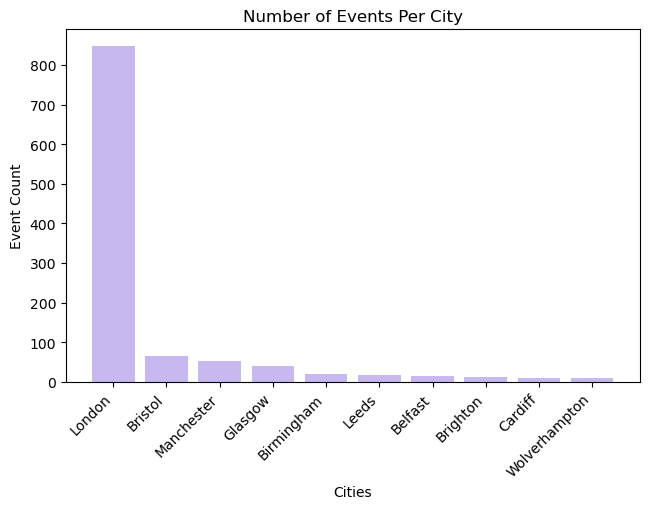

In [41]:
plt.bar(x = city_counts["city"].head(10), height = city_counts["event_count"].head(10), color = [colour_palette[4]])
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.title("Number of Events Per City")
plt.xlabel("Cities")
plt.ylabel("Event Count")
plt.show()

## 4. Venues
Query the Ticketmaster Discovery API for venues in the UK and extract key fields.

In [ ]:
api_key = API_KEY
all_venues = []
current_page = 0
total_pages = 1 

while current_page < total_pages:
    venues_url = f"{BASE_URL}{VENUES_ENDPOINT}.json?apikey={api_key}&countryCode=GB&size=200&page={current_page}"
    venues_response = requests.get(venues_url).json()

    page_venues = venues_response.get('_embedded', {}).get('venues', [])
    all_venues.extend(page_venues)

    total_pages = venues_response.get('page', {}).get('totalPages', 1)
    current_page += 1

print(f"Successfully collected {len(all_venues)} venues total!")

Successfully collected 1200 venues total!


In [9]:
uk_venues = []

for venue in all_venues:
    venue_data = {
        "id":         venue.get("id"),
        "name":       venue.get("name"),
        "city":       venue.get("city", {}).get("name"),
        "country":    venue.get("country", {}).get("name"),
        "longitude":  venue.get("location", {}).get("longitude"),
        "latitude":   venue.get("location", {}).get("latitude"),
        "postcode": venue.get("postalCode")
    }
    uk_venues.append(venue_data)

In [10]:
# Preview the first venue
pprint(uk_venues[0])

{'city': 'Dorset',
 'country': 'Great Britain',
 'id': 'KovZ9177-2f',
 'latitude': '50.73191800',
 'longitude': '-2.75789500',
 'name': 'Bridport Electric Palace',
 'postcode': 'DT63NY'}


In [11]:
df_venues = pd.DataFrame(uk_venues)
df_venues.head()

,id,name,city,country,longitude,latitude,postcode
0,KovZ9177-2f,Bridport Electric Palace,Dorset,Great Britain,-2.75789500,50.73191800,DT63NY
1,KovZ9177-37,St Martin's Theatre,London,Great Britain,-0.12767200,51.51284800,WC2H 9NZ
2,KovZ9177-A0,The Spotlight,Hoddesdon,Great Britain,-0.01507500,51.75569100,EN11 8BE
3,KovZ9177-AV,sohoplace,London,Great Britain,-0.13043600,51.51560700,W1D 3BG
4,KovZ9177-E0,Accu Stadium,Huddersfield,Great Britain,-1.76892400,53.65464900,HD16PG


## 5. Fetch Venue Capacity
Since the Ticketmaster API does not expose capacity data, we fetch it from Wikipedia
using the MediaWiki API. The function searches for each venue by name, pulls the raw
wikitext (infobox) and plain-text extract, then uses regex to extract the capacity value.

# Table of events per venue

In [2]:
cols_to_drop = ['date',	'time', 'multi_day_event', 'legal_age_enforced', 'category_segment', 'category_genre',	'category_sub_genre', 'all_inclusive_pricing','markets', 'markets_id', 'url', 'address','postcode','city']
try:
    df_dropped = df_events.drop(columns=cols_to_drop, errors='ignore')
    print("\nDataFrame after dropping columns:")
    print(df_dropped)
except KeyError as e:
    print(f"Error: {e}")

NameError: name 'df_events' is not defined

In [ ]:
import plotly.express as px

fig = px.bar(
    venue_counts, 
    x="venue_name", 
    y="events_per_venue",
    title="Number of Events per Venue",
    labels={"venue_name": "Venue Name", "events_per_venue": "Number of Events"},
    hover_name="venue_name", # This puts the venue name in bold at the top of the tooltip
    color="events_per_venue",     # Optional: adds a nice color gradient based on counts
    height = 600,
    color_continuous_scale="Viridis"
)


fig.update_layout(
    xaxis_tickangle=-45, # Tilts the venue names so they don't overlap
    plot_bgcolor="rgba(0,0,0,0)" # Gives it a clean white background
)


fig.show()


In [ ]:
import streamlit as st

venue_counts['latitude'] = pd.to_numeric(venue_counts['latitude'], errors='coerce')
venue_counts['longitude'] = pd.to_numeric(venue_counts['longitude'], errors='coerce')

# Remove any rows with invalid coordinates (NaN values)
venue_counts = venue_counts.dropna(subset=['latitude', 'longitude'])

# Create the scatter map with properly formatted numeric coordinates
map = px.scatter_map(
    venue_counts, 
    lat="latitude", 
    lon="longitude", 
    hover_name="venue_name", 
    size="events_per_venue",
    color="events_per_venue",
    zoom=1, 
    height=400
)

# Tell Plotly to use open-street-map (so you don't need a Mapbox API token)
map.update_layout(mapbox_style="open-street-map")
map.update_layout(margin={"r":0,"t":0,"l":0,"b":0})

# Display map in python
map.show()

# Display the map in Streamlit
st.plotly_chart(map)